In [2]:
!pip install ucimlrepo matplotlib seaborn pandas numpy
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

In [8]:
#load and summary

# Fetch dataset
heart_disease = fetch_ucirepo(id=45)

# Extraer features (X) y target (y)
X = heart_disease.data.features
y = heart_disease.data.targets

print(f"Shape (Features): {X.shape}")
print(f"Shape (Target): {y.shape}\n")

print("data types:")
print(X.dtypes)

print("\nvariables:")
print(heart_disease.variables)

print("descriptive analysis:")
display(X.describe())

print(X.head(5))



Shape (Features): (303, 13)
Shape (Target): (303, 1)

data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

variables:
        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None  

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  


In [13]:
# missing values

#show where are the NA
print("missing values before imputation: ")
print(X.isnull().sum()[X.isnull().sum() > 0])


#standarize before KNN and clustering
scaler = StandardScaler()
X_scaled_temp = scaler.fit_transform(X)

#apply KNN to scaled data
knn_imputer = KNNImputer(n_neighbors=5)
X_clean_scaled_temp = knn_imputer.fit_transform(X_scaled_temp)

#undo the scaling
X_clean_original_scale = scaler.inverse_transform(X_clean_scaled_temp)

#conver to final dataset
X_clean = pd.DataFrame(X_clean_original_scale, columns=X.columns)

print("missing values after imputation: ", X_clean.isnull().sum().sum())
print(X_clean.head(3))


missing values before imputation: 
ca      4
thal    2
dtype: int64
missing values after imputation:  0
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   

   slope   ca  thal  
0    3.0  0.0   6.0  
1    2.0  3.0   3.0  
2    2.0  2.0   7.0  


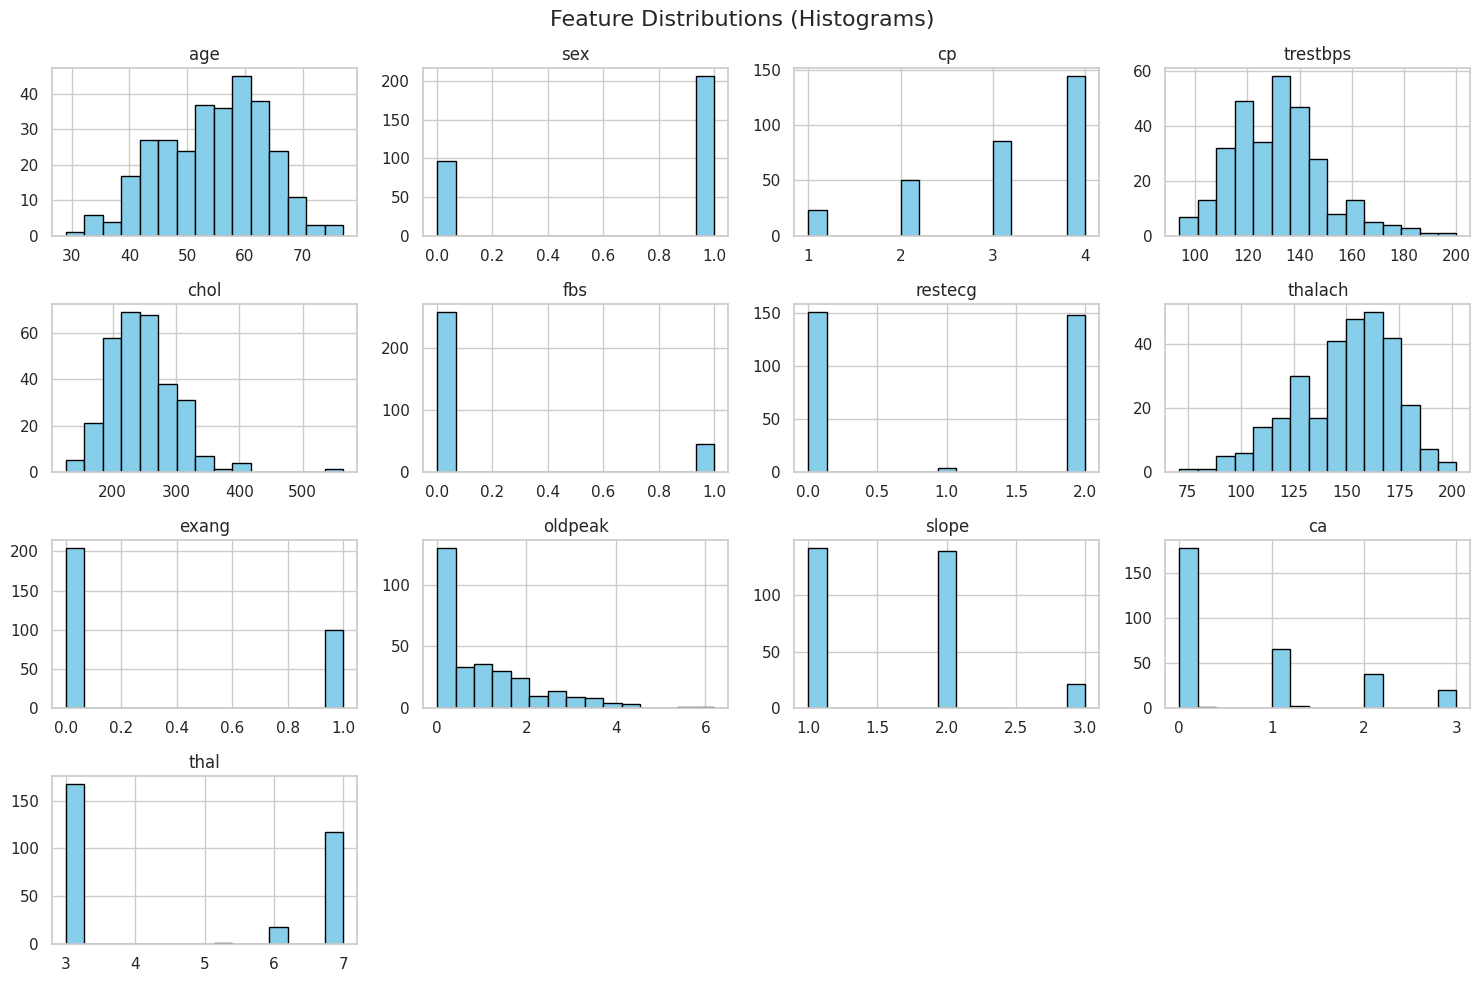

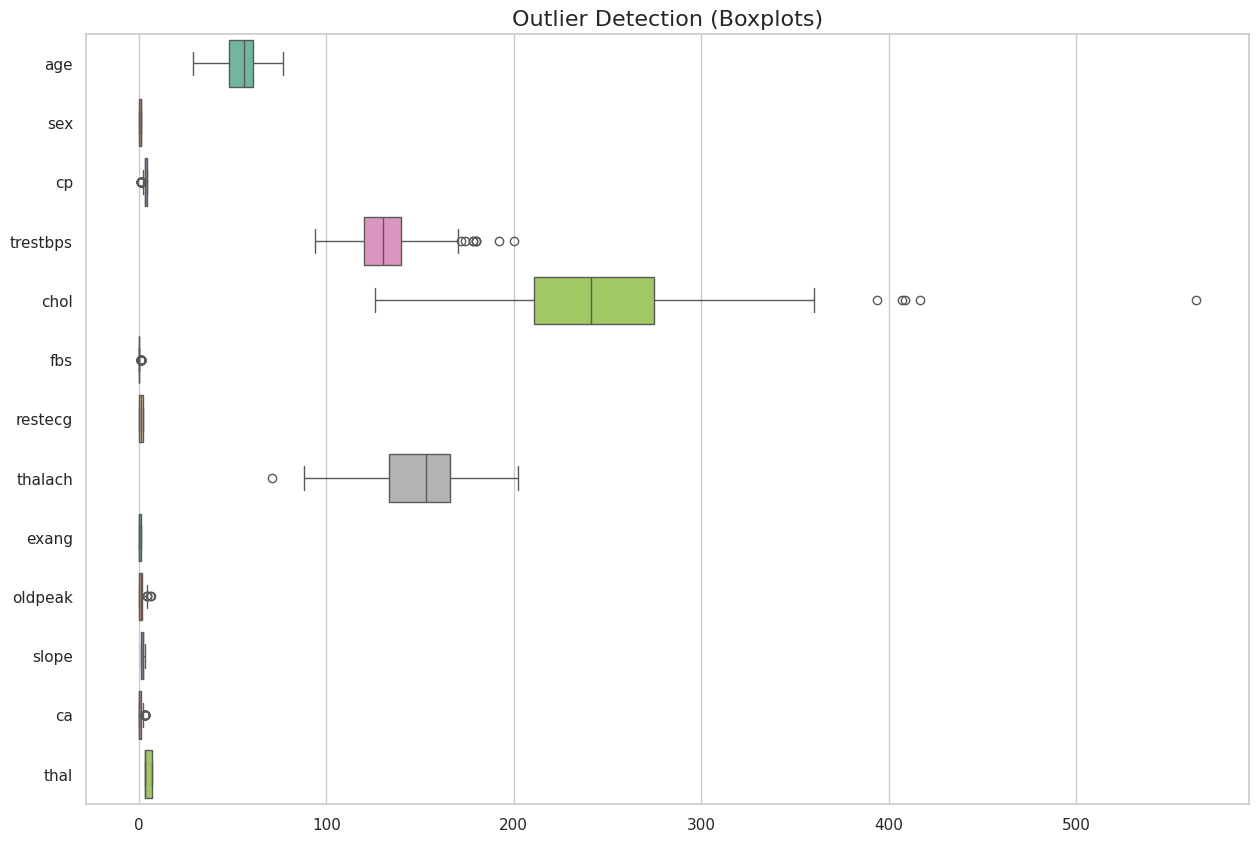

In [14]:
#plots

sns.set_theme(style="whitegrid")

#histograms
X_clean.hist(bins=15, figsize=(15, 10), layout=(4, 4), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

#boxplots
plt.figure(figsize=(15, 10))
sns.boxplot(data=X_clean, orient="h", palette="Set2")
plt.title("Outlier Detection", fontsize=16)
plt.show()

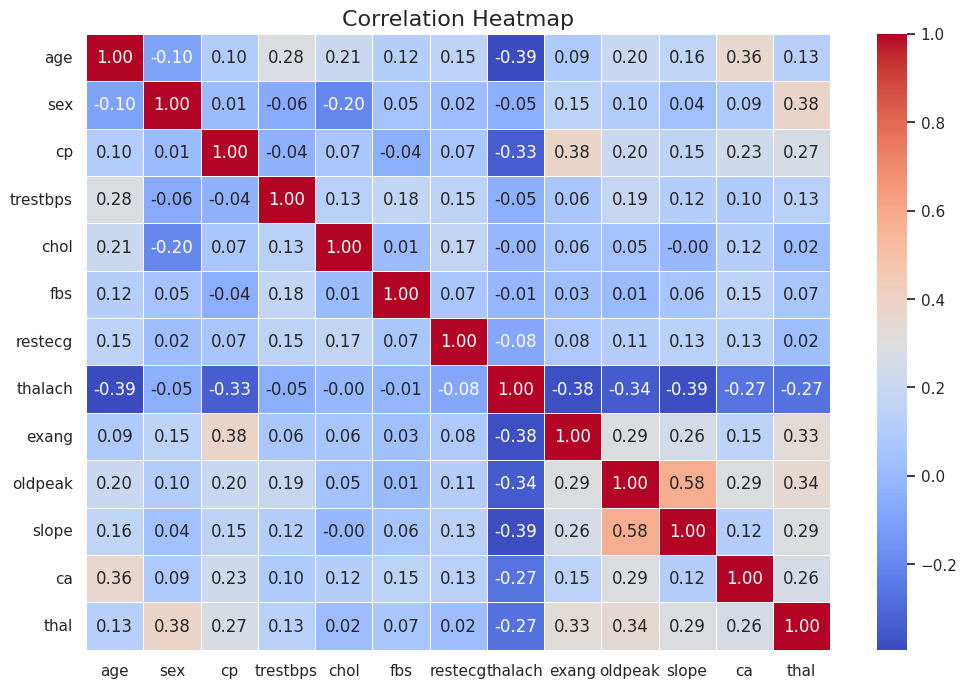

In [15]:
#correlation heatmap

plt.figure(figsize=(12, 8))
corr_matrix = X_clean.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()